In [1]:
# typical Python libraries
import numpy as np
import matplotlib.pyplot as plt

# Libraries to read data from internet
import requests

# PyTorch Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import clip_grad_norm

# Hugging Face libraries
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset

import textwrap
#

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Import GPT-2 Large

In [3]:
gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2-large")
gpt2_model = AutoModelForCausalLM.from_pretrained("gpt2-large").to(device)
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [4]:
print(f'{sum(p.numel() for p in gpt2_model.parameters()):,} parameters')

774,030,080 parameters


In [5]:
# https://huggingface.co/datasets/THUDM/webglm-qa
dataset = load_dataset('THUDM/webglm-qa')

README.md: 0.00B [00:00, ?B/s]

data/train.jsonl:   0%|          | 0.00/115M [00:00<?, ?B/s]

data/validation.jsonl:   0%|          | 0.00/2.63M [00:00<?, ?B/s]

data/test.jsonl:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [6]:
# Find the number of tokens for questions and answers in train dataset
train_len = np.zeros((len(dataset['train']),2))

for i in range(len(dataset['train'])):
    train_len[i,0] = len(gpt2_tokenizer(dataset['train']['question'][i])['input_ids'])
    train_len[i,1] = len(gpt2_tokenizer(dataset['train']['answer'][i])['input_ids'])

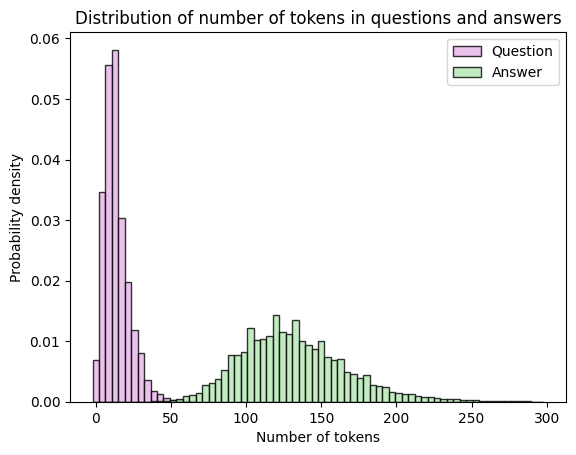

In [7]:
# Plot histogram on the distribution of questions and answers in train dataset
binedges = np.linspace(0, 300, 71)

yQ, xQ = np.histogram(train_len[:,0], bins=binedges, density=True)
yA, xA = np.histogram(train_len[:,1], bins=binedges, density=True)

plt.bar(xQ[:-1], yQ, width=binedges[1]-binedges[0], edgecolor='k', facecolor=[.9,.7,.9], alpha=0.8,label='Question')
plt.bar(xA[:-1], yA, width=binedges[1]-binedges[0], edgecolor='k',facecolor=[.7,.9,.7], alpha=0.8,label='Answer')

plt.xlabel('Number of tokens')
plt.ylabel('Probability density')
plt.title('Distribution of number of tokens in questions and answers')

plt.legend(loc='upper right')
plt.show();

In [8]:
# Create train and test datasets with a sequence length of 256 from train and validation tokens. The size of the train dataset should be 10,000 x sequence length and test dataset drawn from validation tokens of size 1000 x sequence length. If the length of the tokens < sequence length the extra spaces should be padded by EOS tokens

seq_length = 256
train_tokens = torch.full((10000, seq_length), gpt2_tokenizer.eos_token_id)
test_tokens = torch.full((1000, seq_length), gpt2_tokenizer.eos_token_id)


for i in range(train_tokens.shape[0]):
  qa = f'QUESTION: {dataset['train']['question'][i]} ANSWER: {dataset['train']['answer'][i]}'
  qa_tokens = gpt2_tokenizer.encode(qa)

  j = min(len(qa_tokens), seq_length)
  train_tokens[i, :j] = torch.tensor(qa_tokens[:j])


for i in range(test_tokens.shape[0]):
  qa = f'QUESTION: {dataset['validation']['question'][i]} ANSWER: {dataset['validation']['answer'][i]}'
  qa_tokens = gpt2_tokenizer.encode(qa)

  j = min(len(qa_tokens), seq_length)
  test_tokens[i, :j] = torch.tensor(qa_tokens[:j])

In [9]:
# attention mask
attn_mask = (train_tokens[0] != gpt2_tokenizer.pad_token_id).long()

print(f'Training tokens:\n{train_tokens[0]}\n')
print(f'Attention mask:\n{attn_mask}')

Training tokens:
tensor([35780,  2849,    25,   287,  4346, 45038,   262,   966,   286, 24430,
          262,   717,   734,  5341,   351,   257, 10484,   532,   510,   262,
         3504,   532,   407,  3218, 10484,  5341,  1312,   651,   883,  3537,
        17887,  1137,    25,   383,   966,   286, 24430,   262,   717,   734,
         5341,   351,   257, 10484,   510,   262,  3504,   318,   284,  1011,
         4621,   286,   262,  2319,  1218,   711,  8801,   290,   262,   734,
         5664,  6509,   287,  4708,   290,  4152,  4346,  1830,    13,  2750,
         2491,   262,  2613,  3264,   510,   262,  3504,    11,   262,  6907,
         7176,   284,   307,  1498,   284,  2512,  2506,   510,   290,   262,
         2491,   736,   460,   787,   257,  1048,  2051,   290,   886,   510,
          287,   262,   886,  6516,    58,    17,  4083, 18162,   510,   262,
         3504,   318,   635,   262, 35581,  3108,   284,   262,   886,  6516,
           11,   523,   340,   318,  1690,  356

In [10]:
# check a random batch
ix = np.random.randint(0,train_tokens[0].shape,8)
X  = train_tokens[ix]
attn_mask = (X != gpt2_tokenizer.pad_token_id).long()


print(f'Size of batch: {X.shape}')
print(f'Size of attention mask: {attn_mask.shape}\n')

print('Some examples:')
for t in range(5):
  print(f'*** Example: \n',textwrap.fill(gpt2_tokenizer.decode(X[t]),123),'\n')

Size of batch: torch.Size([8, 256])
Size of attention mask: torch.Size([8, 256])

Some examples:
*** Example: 
 QUESTION: How do service animals help autistic children? ANSWER: Service animals can help autistic children in a variety of
ways. They can provide constant positive companionship, make difficult transitions easier, perform specific tasks, and
reduce stress and anxiety[2]. They can also help to deflect emotions in negative situations, and help the child to focus on
positive activities instead of their own distress[2]. Service animals are also trained to recognize and gently interrupt
self-harming behaviors or help de-escalate an emotional meltdown[4]. Finally, they should be treated primarily as a tool
that can be used to help the child with autism, and not as a family pet[5].<|endoftext|><|endoftext|><|endoftext|><|endofte
xt|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|
endoftext|><|endoftext|><|endof

In [11]:
aveAM = (train_tokens == gpt2_tokenizer.pad_token_id).sum()/torch.numel(train_tokens)
print(f'{aveAM*100:5.2f}% of TRAIN token positions are EOS.')

aveAM = (test_tokens == gpt2_tokenizer.pad_token_id).sum()/torch.numel(test_tokens)
print(f'{aveAM*100:5.2f}% of TEST token positions are EOS.')

38.86% of TRAIN token positions are EOS.
38.57% of TEST token positions are EOS.


In [12]:
batch_size  =   8
num_samples = 123

optimizer = torch.optim.Adam(gpt2_model.parameters(), lr=1e-5)

# initialize losses
train_loss = np.zeros(num_samples)
test_loss  = np.zeros(num_samples)

gpt2_model.to(device)
gpt2_model.train()


for sampli in range(num_samples):

  # get a batch of data and create a mask
  ix = np.random.randint(0,train_tokens[0].shape,batch_size)
  X  = train_tokens[ix]
  attn_mask = (X != gpt2_tokenizer.pad_token_id).long()

  # move data to GPU
  attn_mask = attn_mask.to(device)
  X = X.to(device)

  # forward pass (Hugging Face shifts X internally to get y)
  gpt2_model.zero_grad()
  outputs = gpt2_model(X,labels=X,attention_mask=attn_mask)
  loss = outputs.loss

  # backprop
  loss.backward()
  optimizer.step()

  # store the per-sample loss
  train_loss[sampli] = loss.item()

  # test and update progress display
  if sampli%5==0:

    # get a batch of data and create a mask
    ix = np.random.randint(0,test_tokens[0].shape,batch_size)
    X  = test_tokens[ix]
    attn_mask = (X != gpt2_tokenizer.pad_token_id).long()

    # move data to GPU
    attn_mask, X = attn_mask.to(device), X.to(device)

    # forward pass and get loss
    with torch.no_grad():
      gpt2_model.eval()
      outputs = gpt2_model(X,labels=X,attention_mask=attn_mask)
      test_loss[sampli] = outputs.loss.item()

    # report progress
    print(f'Sample {sampli:4}/{num_samples}, train/test loss: {train_loss[sampli]:.4f}/{test_loss[sampli]:.4f}')

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Sample    0/123, train/test loss: 6.1868/5.2338
Sample    5/123, train/test loss: 1.9920/1.7957
Sample   10/123, train/test loss: 1.8418/1.5826
Sample   15/123, train/test loss: 1.4901/1.5625
Sample   20/123, train/test loss: 1.5103/1.6416
Sample   25/123, train/test loss: 1.4958/1.5421
Sample   30/123, train/test loss: 1.5512/1.5895
Sample   35/123, train/test loss: 1.1611/1.4843
Sample   40/123, train/test loss: 1.3973/1.5088
Sample   45/123, train/test loss: 1.7207/1.6020
Sample   50/123, train/test loss: 1.3979/1.3635
Sample   55/123, train/test loss: 1.1935/1.5356
Sample   60/123, train/test loss: 1.1222/1.3793
Sample   65/123, train/test loss: 1.5173/1.4934
Sample   70/123, train/test loss: 1.7028/1.5964
Sample   75/123, train/test loss: 1.2666/1.3678
Sample   80/123, train/test loss: 1.1973/1.5465
Sample   85/123, train/test loss: 1.1381/1.3364
Sample   90/123, train/test loss: 1.1061/1.5173
Sample   95/123, train/test loss: 0.9381/1.6173
Sample  100/123, train/test loss: 1.3529

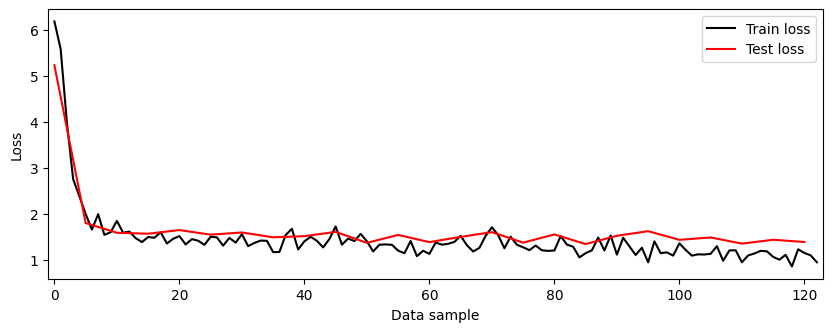

In [13]:
# plot the losses
plt.figure(figsize=(10,3.5))
plt.plot(train_loss,'k',label='Train loss')
x4test = np.where(test_loss)[0]
plt.plot(x4test,test_loss[x4test],'r',label='Test loss')

plt.legend()
plt.gca().set(xlabel='Data sample',ylabel='Loss',xlim=[-1,num_samples])
plt.show()

In [18]:
# Qualtative assessment
prompt = 'QUESTION: Where does the word "butterfly" come from?'
# prompt = 'QUESTION: Would it be strange to have a pet rock and feed it styrofoam?'
in2gpt = torch.tensor(gpt2_tokenizer.encode(prompt)).unsqueeze(0).to(device)

output = gpt2_model.generate(in2gpt,do_sample=True,max_length=200,pad_token_id=50256)
print(textwrap.fill(gpt2_tokenizer.decode(output[0]),80))

QUESTION: Where does the word "butterfly" come from? ANSWER: The word
"butterfly" comes from the Greek word ψχεχη (buterax), which means swarming or
swarm[1]. The Middle English spelling of anders is from the Old English word
anders, meaning a swarm[2]. The word was probably first attested in England in
the 12th century, but its etymological roots are unclear[2][3].<|endoftext|>
